In [100]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import string
import nltk
import nltk
nltk.download('punkt', download_dir=r'C:\Users\hp\AppData\Roaming\nltk_data')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import joblib
# pour (dé)sérialiser vos modèles et vos jeux de données
import joblib

# les métriques
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# pour la validation croisée du meilleur modèle
from sklearn.model_selection import cross_val_score

# les algorithmes que vous instanciez plus bas
from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import SVC
from sklearn.naive_bayes     import MultinomialNB
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [101]:
# Configuration pour l'affichage en arabe
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False

In [102]:
print("Étape 0: Chargement du dataset original")



Étape 0: Chargement du dataset original


In [103]:
df= pd.read_csv(r"C:\Users\hp\Downloads\MAC corpus.csv", sep=',', encoding='utf-8')

In [104]:
df.shape

(18087, 3)

In [105]:
df.head()

,tweets,type,class
0,ماهي آرائكم متتبعي الكرام,neutral,standard;;
1,عبقرية المدرب وروعة اللاعبين,positive,standard;;
2,أمة عربية واحدة خالدة,positive,standard;;
3,عاد إليكم من جديد وأخيرا درت جيم لهاد الصفحة,neutral,dialectal;;
4,الله يخلف عليك سيدي محمد,positive,dialectal;;


In [106]:
df['class'] = df['class'].str.replace(';', '', regex=False)


In [107]:
df.head()

,tweets,type,class
0,ماهي آرائكم متتبعي الكرام,neutral,standard
1,عبقرية المدرب وروعة اللاعبين,positive,standard
2,أمة عربية واحدة خالدة,positive,standard
3,عاد إليكم من جديد وأخيرا درت جيم لهاد الصفحة,neutral,dialectal
4,الله يخلف عليك سيدي محمد,positive,dialectal


In [108]:
print("\nValeurs uniques dans la colonne 'class':")
print(df['class'].value_counts())


Valeurs uniques dans la colonne 'class':
class
standard     12611
dialectal     5464
diatectal       12
Name: count, dtype: int64


In [109]:
df['class'] = df['class'].replace('diatectal', 'dialectal')


In [110]:
print("Valeurs uniques après correction :")
print(df['class'].value_counts())

Valeurs uniques après correction :
class
standard     12611
dialectal     5476
Name: count, dtype: int64


In [111]:
# Vérifier les valeurs uniques dans les colonnes d'étiquettes
print("Valeurs uniques dans la colonne 'type':")
print(df['type'].value_counts())

Valeurs uniques dans la colonne 'type':
type
positive    9897
neutral     4039
negative    3508
mixed        643
Name: count, dtype: int64


In [112]:
df.drop(df[df['type'] == 'mixed'].index, inplace=True)

In [113]:
# Vérifier les valeurs uniques dans les colonnes d'étiquettes
print("Valeurs uniques dans la colonne 'type':")
print(df['type'].value_counts())

Valeurs uniques dans la colonne 'type':
type
positive    9897
neutral     4039
negative    3508
Name: count, dtype: int64


In [114]:
print("\nÉtape 1: Nettoyage des données")


Étape 1: Nettoyage des données


In [115]:
df.columns

Index(['tweets', 'type', 'class'], dtype='object')

In [116]:
# Fonction de nettoyage complète
def clean_tweet(text):
    if pd.isna(text):
        return ""
    
    # Convertir en string si ce n'est pas déjà le cas
    text = str(text)
    
    # Supprimer les ;; en fin de ligne
    text = re.sub(r";;$", "", text)
    
    # Supprimer les URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # Supprimer les mentions (@utilisateur)
    text = re.sub(r'@\w+', '', text)
    
    # Supprimer les hashtags (#mot) - on peut conserver le mot sans le #
    text = re.sub(r'#(\w+)', r'\1', text)
    
    # Supprimer les caractères spéciaux non arabes et non alphanumériques
    text = re.sub(r'[^\u0600-\u06FF\w\s]', ' ', text)
    
    # Normaliser les espaces multiples
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

In [117]:
# Appliquer le nettoyage
df['tweets_clean'] = df['tweets'].apply(clean_tweet)

In [118]:
# Afficher quelques exemples avant/après nettoyage
print("Exemples de tweets avant et après nettoyage:")
for i in range(min(10, len(df))):
    print(f"Original: {df['tweets'].iloc[i]}")
    print(f"Nettoyé: {df['tweets_clean'].iloc[i]}")
    print("-" * 50)

Exemples de tweets avant et après nettoyage:
Original: ماهي آرائكم متتبعي الكرام
Nettoyé: ماهي آرائكم متتبعي الكرام
--------------------------------------------------
Original: عبقرية المدرب وروعة اللاعبين
Nettoyé: عبقرية المدرب وروعة اللاعبين
--------------------------------------------------
Original: أمة عربية واحدة خالدة 
Nettoyé: أمة عربية واحدة خالدة
--------------------------------------------------
Original: عاد إليكم من جديد وأخيرا درت جيم لهاد الصفحة
Nettoyé: عاد إليكم من جديد وأخيرا درت جيم لهاد الصفحة
--------------------------------------------------
Original: الله يخلف عليك سيدي محمد
Nettoyé: الله يخلف عليك سيدي محمد
--------------------------------------------------
Original: أشارك في تمام الساعة في نشرة أخبار الجزيرة لمناقشة التوتر السعودي المغربي وسحب الرباط سفيرها من الرياض
Nettoyé: أشارك في تمام الساعة في نشرة أخبار الجزيرة لمناقشة التوتر السعودي المغربي وسحب الرباط سفيرها من الرياض
--------------------------------------------------
Original: هجومك يا أخي على حسن طار

In [119]:
print("\nÉtape 2: Normalisation du texte")


Étape 2: Normalisation du texte


In [120]:
def normalize_text(text):
    if pd.isna(text) or text == "":
        return ""
    
    # Convertir en minuscules les caractères non arabes
    text_parts = []
    for char in text:
        if '\u0600' <= char <= '\u06FF':  # Caractères arabes
            text_parts.append(char)
        else:
            text_parts.append(char.lower())
    
    text = ''.join(text_parts)
    
    # Supprimer les répétitions de lettres (plus de 2 occurrences consécutives)
    # Par exemple: سسسسسلام -> سسلام
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    
    return text

In [121]:
df['tweets_normalized'] = df['tweets_clean'].apply(normalize_text)

In [122]:
print("Exemples de tweets après normalisation:")
for i in range(min(12, len(df))):
    print(f"Nettoyé: {df['tweets_clean'].iloc[i]}")
    print(f"Normalisé: {df['tweets_normalized'].iloc[i]}")
    print("-" * 50)

Exemples de tweets après normalisation:
Nettoyé: ماهي آرائكم متتبعي الكرام
Normalisé: ماهي آرائكم متتبعي الكرام
--------------------------------------------------
Nettoyé: عبقرية المدرب وروعة اللاعبين
Normalisé: عبقرية المدرب وروعة اللاعبين
--------------------------------------------------
Nettoyé: أمة عربية واحدة خالدة
Normalisé: أمة عربية واحدة خالدة
--------------------------------------------------
Nettoyé: عاد إليكم من جديد وأخيرا درت جيم لهاد الصفحة
Normalisé: عاد إليكم من جديد وأخيرا درت جيم لهاد الصفحة
--------------------------------------------------
Nettoyé: الله يخلف عليك سيدي محمد
Normalisé: الله يخلف عليك سيدي محمد
--------------------------------------------------
Nettoyé: أشارك في تمام الساعة في نشرة أخبار الجزيرة لمناقشة التوتر السعودي المغربي وسحب الرباط سفيرها من الرياض
Normalisé: أشارك في تمام الساعة في نشرة أخبار الجزيرة لمناقشة التوتر السعودي المغربي وسحب الرباط سفيرها من الرياض
--------------------------------------------------
Nettoyé: هجومك يا أخي على حسن طارق

In [123]:
# 3. Tokenisation
print("\nÉtape 3: Tokenisation")


Étape 3: Tokenisation


In [124]:
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

In [125]:
def tokenize_arabic(text):
    if pd.isna(text) or text == "":
        return []
    
    # Tokenisation simple par espace pour l'arabe/darija
    # On peut aussi utiliser NLTK avec des règles personnalisées
    tokens = word_tokenize(text)
    
    return tokens

In [126]:
df['tokens'] = df['tweets_normalized'].apply(tokenize_arabic)


In [127]:
df['tokens'] = df['tweets_normalized'].apply(tokenize_arabic)

print("Exemples de tweets tokenisés:")
for i in range(min(5, len(df))):
    print(f"Normalisé: {df['tweets_normalized'].iloc[i]}")
    print(f"Tokens: {df['tokens'].iloc[i]}")
    print("-" * 50)

Exemples de tweets tokenisés:
Normalisé: ماهي آرائكم متتبعي الكرام
Tokens: ['ماهي', 'آرائكم', 'متتبعي', 'الكرام']
--------------------------------------------------
Normalisé: عبقرية المدرب وروعة اللاعبين
Tokens: ['عبقرية', 'المدرب', 'وروعة', 'اللاعبين']
--------------------------------------------------
Normalisé: أمة عربية واحدة خالدة
Tokens: ['أمة', 'عربية', 'واحدة', 'خالدة']
--------------------------------------------------
Normalisé: عاد إليكم من جديد وأخيرا درت جيم لهاد الصفحة
Tokens: ['عاد', 'إليكم', 'من', 'جديد', 'وأخيرا', 'درت', 'جيم', 'لهاد', 'الصفحة']
--------------------------------------------------
Normalisé: الله يخلف عليك سيدي محمد
Tokens: ['الله', 'يخلف', 'عليك', 'سيدي', 'محمد']
--------------------------------------------------


In [128]:
# 4. Gestion des mots vides (stopwords)
print("\nÉtape 4: Gestion des mots vides (stopwords)")


Étape 4: Gestion des mots vides (stopwords)


In [129]:
 #Définir une liste de stopwords en arabe/darija
# Cette liste est un exemple, vous devrez la personnaliser pour la darija marocaine
try:
    arabic_stopwords = set(stopwords.words('arabic'))
except LookupError:
    nltk.download('stopwords')
    arabic_stopwords = set(stopwords.words('arabic'))

# Ajouter des stopwords spécifiques à la darija marocaine
darija_stopwords = {
    'و', 'في', 'هذا', 'يا', 'على', 'من', 'ما', 'لي', 'هاد', 'كان', 
    'هي', 'هو', 'غادي', 'باش', 'دابا', 'كنت', 'كن', 'كيف', 'واخا', 
    'واش', 'عند', 'عندي', 'كاين', 'كاينة', 'ديال', 'ديالي', 'ديالك',
    'فيه', 'فيها', 'انا', 'انت', 'هوا', 'هيا', 'احنا', 'نتا', 'نتي'
}


In [130]:
# Combiner les deux ensembles de stopwords
stopwords_set = arabic_stopwords.union(darija_stopwords)

In [131]:
def remove_stopwords(tokens):
    if not tokens:
        return []
    
    return [token for token in tokens if token not in stopwords_set]

df['tokens_no_stopwords'] = df['tokens'].apply(remove_stopwords)

In [132]:
print("Exemples de tweets après suppression des stopwords:")
for i in range(min(5, len(df))):
    print(f"Tokens avec stopwords: {df['tokens'].iloc[i]}")
    print(f"Tokens sans stopwords: {df['tokens_no_stopwords'].iloc[i]}")
    print("-" * 50)

Exemples de tweets après suppression des stopwords:
Tokens avec stopwords: ['ماهي', 'آرائكم', 'متتبعي', 'الكرام']
Tokens sans stopwords: ['ماهي', 'آرائكم', 'متتبعي', 'الكرام']
--------------------------------------------------
Tokens avec stopwords: ['عبقرية', 'المدرب', 'وروعة', 'اللاعبين']
Tokens sans stopwords: ['عبقرية', 'المدرب', 'وروعة', 'اللاعبين']
--------------------------------------------------
Tokens avec stopwords: ['أمة', 'عربية', 'واحدة', 'خالدة']
Tokens sans stopwords: ['أمة', 'عربية', 'واحدة', 'خالدة']
--------------------------------------------------
Tokens avec stopwords: ['عاد', 'إليكم', 'من', 'جديد', 'وأخيرا', 'درت', 'جيم', 'لهاد', 'الصفحة']
Tokens sans stopwords: ['جديد', 'وأخيرا', 'درت', 'لهاد', 'الصفحة']
--------------------------------------------------
Tokens avec stopwords: ['الله', 'يخلف', 'عليك', 'سيدي', 'محمد']
Tokens sans stopwords: ['الله', 'يخلف', 'سيدي', 'محمد']
--------------------------------------------------


In [133]:
# 5. Lemmatisation/Racinisation (Stemming)
print("\nÉtape 5: Lemmatisation/Racinisation")


Étape 5: Lemmatisation/Racinisation


In [134]:
# Remarque: Pour une stématisation complète de l'arabe, il est recommandé d'utiliser
# des bibliothèques spécialisées comme PyArabic, Farasa ou CAMeL Tools.
# Ici, nous utilisons une approche simplifiée pour la démonstration.

# Fonction de racinisation simple (à remplacer par une solution plus robuste)
def simple_arabic_stem(word):
    # Cette fonction est très simplifiée et ne doit être utilisée qu'à des fins de démonstration
    # Supprime les préfixes courants en arabe
    prefixes = ['ال', 'بال', 'كال', 'لل', 'و', 'ف', 'ب', 'ل', 'س', 'ي', 'ت', 'ن']
    
    for prefix in prefixes:
        if word.startswith(prefix) and len(word) > len(prefix) + 2:
            word = word[len(prefix):]
            break
    
    # Supprime les suffixes courants en arabe
    suffixes = ['ون', 'ين', 'ات', 'ة', 'ه', 'ي', 'ك', 'ها', 'هم', 'هن', 'كم', 'كن', 'نا']
    
    for suffix in suffixes:
        if word.endswith(suffix) and len(word) > len(suffix) + 2:
            word = word[:-len(suffix)]
            break
    
    return word

In [135]:
def stem_tokens(tokens):
    if not tokens:
        return []
    
    return [simple_arabic_stem(token) for token in tokens]

In [136]:
df['tokens_stemmed'] = df['tokens_no_stopwords'].apply(stem_tokens)
print("Exemples de tweets après racinisation:")
for i in range(min(5, len(df))):
    print(f"Tokens sans stopwords: {df['tokens_no_stopwords'].iloc[i]}")
    print(f"Tokens racinisés: {df['tokens_stemmed'].iloc[i]}")
    print("-" * 50)

Exemples de tweets après racinisation:
Tokens sans stopwords: ['ماهي', 'آرائكم', 'متتبعي', 'الكرام']
Tokens racinisés: ['ماه', 'آرائ', 'متتبع', 'كرام']
--------------------------------------------------
Tokens sans stopwords: ['عبقرية', 'المدرب', 'وروعة', 'اللاعبين']
Tokens racinisés: ['عبقري', 'مدرب', 'روع', 'لاعب']
--------------------------------------------------
Tokens sans stopwords: ['أمة', 'عربية', 'واحدة', 'خالدة']
Tokens racinisés: ['أمة', 'عربي', 'احد', 'خالد']
--------------------------------------------------
Tokens sans stopwords: ['جديد', 'وأخيرا', 'درت', 'لهاد', 'الصفحة']
Tokens racinisés: ['جديد', 'أخيرا', 'درت', 'هاد', 'صفح']
--------------------------------------------------
Tokens sans stopwords: ['الله', 'يخلف', 'سيدي', 'محمد']
Tokens racinisés: ['الل', 'خلف', 'يدي', 'محمد']
--------------------------------------------------


In [137]:
# Rejoindre les tokens pour former un texte prétraité complet
df['preprocessed_text'] = df['tokens_stemmed'].apply(lambda x: ' '.join(x))

In [138]:
# 6. Vérification des étiquettes
print("\nÉtape 6: Vérification et encodage des étiquettes")


Étape 6: Vérification et encodage des étiquettes


In [139]:
type_mapping = {"neutral": 0, "positive": 1, "negative": 2, "mixed": 3}
class_mapping = {"standard": 0, "dialectal": 1}

In [140]:
# Vérifier si toutes les valeurs sont dans les mappings
missing_types = set(df['type'].unique()) - set(type_mapping.keys())
missing_classes = set(df['class'].unique()) - set(class_mapping.keys())

if missing_types:
    print(f"Attention: Valeurs inattendues dans 'type': {missing_types}")
if missing_classes:
    print(f"Attention: Valeurs inattendues dans 'class': {missing_classes}")

In [141]:
 #Appliquer le mapping et gérer les valeurs manquantes
df['type_encoded'] = df['type'].map(type_mapping)
df['class_encoded'] = df['class'].map(class_mapping)

In [142]:
 #Vérifier les lignes avec des NaN après encodage
nan_rows = df[df['type_encoded'].isna() | df['class_encoded'].isna()]
if not nan_rows.empty:
    print(f"\nNombre de lignes avec des étiquettes manquantes: {len(nan_rows)}")
    print("Exemples de lignes avec des étiquettes manquantes:")
    print(nan_rows.head())
    
    # Supprimer les lignes avec des étiquettes manquantes
    df = df.dropna(subset=['type_encoded', 'class_encoded'])
    print(f"Dimensions après suppression des lignes avec étiquettes manquantes: {df.shape}")

In [143]:
print("\nÉtape 7: Suppression des doublons")


Étape 7: Suppression des doublons


In [144]:
duplicate_count = df.duplicated(subset=['preprocessed_text']).sum()
print(f"Nombre de tweets en double: {duplicate_count}")

Nombre de tweets en double: 5694


In [145]:
df_no_duplicates = df.drop_duplicates(subset=['preprocessed_text'])
print(f"Dimensions après suppression des doublons: {df_no_duplicates.shape}")

Dimensions après suppression des doublons: (11750, 11)


In [146]:
# 8. Vectorisation
print("\nÉtape 8: Vectorisation")


Étape 8: Vectorisation


In [147]:
# Vectorisation TF-IDF
vectorizer = TfidfVectorizer(
    min_df=2,         # Ignorer les termes qui apparaissent dans moins de 2 documents
    max_df=0.85,      # Ignorer les termes qui apparaissent dans plus de 85% des documents
    ngram_range=(1, 2)  # Unigrams et bigrams
)

In [148]:
# Créer la matrice TF-IDF
X_tfidf = vectorizer.fit_transform(df_no_duplicates['preprocessed_text'])

In [149]:
print(f"Dimensions de la matrice TF-IDF: {X_tfidf.shape}")
print(f"Nombre de caractéristiques: {len(vectorizer.get_feature_names_out())}")

Dimensions de la matrice TF-IDF: (11750, 11002)
Nombre de caractéristiques: 11002


In [150]:
# Afficher les 10 premières caractéristiques
print("Premières caractéristiques:")
print(vectorizer.get_feature_names_out()[:10])

Premières caractéristiques:
['آباء' 'آباء مسلم' 'آبناء' 'آت' 'آتنا' 'آتنا دنيا' 'آتي' 'آجل' 'آحب'
 'آحد']


In [151]:
# 9. Équilibrage des classes
print("\nÉtape 9: Analyse de l'équilibre des classes")


Étape 9: Analyse de l'équilibre des classes


In [152]:
 #Distribution des classes de sentiment
print("Distribution des classes de sentiment:")
print(df_no_duplicates['type_encoded'].value_counts())
print("\nDistribution des classes de dialecte:")
print(df_no_duplicates['class_encoded'].value_counts())

Distribution des classes de sentiment:
type_encoded
1    6088
0    2985
2    2677
Name: count, dtype: int64

Distribution des classes de dialecte:
class_encoded
0    8293
1    3457
Name: count, dtype: int64


In [153]:
# Visualiser la distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df_no_duplicates['type_encoded'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution des classes de sentiment')
plt.xlabel('Type de sentiment')
plt.ylabel('Nombre de tweets')
plt.xticks(ticks=range(len(type_mapping)), labels=[k for k in type_mapping.keys()])

plt.subplot(1, 2, 2)
df_no_duplicates['class_encoded'].value_counts().plot(kind='bar', color='lightgreen')
plt.title('Distribution des classes de dialecte')
plt.xlabel('Type de dialecte')
plt.ylabel('Nombre de tweets')
plt.xticks(ticks=range(len(class_mapping)), labels=[k for k in class_mapping.keys()])

plt.tight_layout()
plt.savefig('class_distribution.png')
plt.close()



In [154]:
# Équilibrage des classes (si nécessaire)
# Nous nous concentrons ici sur l'équilibrage des classes de sentiment
sentiment_counts = df_no_duplicates['type_encoded'].value_counts()
min_class_size = sentiment_counts.min()
max_class_size = sentiment_counts.max()
imbalance_ratio = max_class_size / min_class_size

print(f"\nRatio de déséquilibre: {imbalance_ratio:.2f}")


Ratio de déséquilibre: 2.27


In [155]:
if imbalance_ratio > 2:
    print("Équilibrage des classes avec sous-échantillonnage:")
    
    # Sous-échantillonnage (downsample) des classes majoritaires
    balanced_dfs = []
    
    for class_val in df_no_duplicates['type_encoded'].unique():
        class_df = df_no_duplicates[df_no_duplicates['type_encoded'] == class_val]
        
        # Si la classe est plus grande que la classe minimale, sous-échantillonner
        if len(class_df) > min_class_size:
            downsampled = resample(
                class_df,
                replace=False,           # Sans remplacement
                n_samples=min_class_size, # Taille de la classe minoritaire
                random_state=42           # Pour reproductibilité
            )
            balanced_dfs.append(downsampled)
        else:
            balanced_dfs.append(class_df)
    
    # Combiner les DataFrames équilibrés
    df_balanced = pd.concat(balanced_dfs)
    
    print("Distribution après équilibrage:")
    print(df_balanced['type_encoded'].value_counts())
    
    # Mettre à jour le DataFrame principal
    df_no_duplicates = df_balanced
    
    # Recalculer la matrice TF-IDF avec les données équilibrées
    X_tfidf = vectorizer.fit_transform(df_no_duplicates['preprocessed_text'])
    print(f"Nouvelles dimensions de la matrice TF-IDF: {X_tfidf.shape}")

Équilibrage des classes avec sous-échantillonnage:
Distribution après équilibrage:
type_encoded
0    2677
1    2677
2    2677
Name: count, dtype: int64
Nouvelles dimensions de la matrice TF-IDF: (8031, 8024)


In [156]:
 #10.

In [157]:
# Préparer le dataframe final pour l'export
df_final = df_no_duplicates[[
    'tweets',                # Texte original
    'tweets_clean',          # Texte nettoyé
    'preprocessed_text',     # Texte prétraité complet
    'type', 'type_encoded',  # Étiquettes de sentiment
    'class', 'class_encoded' # Étiquettes de dialecte
]]


In [158]:
df_final.to_csv("MAC_corpus_clean.csv", index=False)
print("Données prétraitées sauvegardées sous 'MAC_corpus_clean.csv'")

Données prétraitées sauvegardées sous 'MAC_corpus_clean.csv'


In [159]:
print("\nPréparation des données pour l'apprentissage automatique")


Préparation des données pour l'apprentissage automatique


In [160]:
# Diviser en ensembles d'entraînement et de test
X = X_tfidf
y = df_no_duplicates['type_encoded'].values
y_dialect = df_no_duplicates['class_encoded'].values

X_train, X_test, y_train, y_test, y_train_dialect, y_test_dialect = train_test_split(
    X,y, y_dialect, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Stratifier selon le sentiment
)

print(f"Ensemble d'entraînement: {X_train.shape[0]} exemples")
print(f"Ensemble de test: {X_test.shape[0]} exemples")

Ensemble d'entraînement: 6424 exemples
Ensemble de test: 1607 exemples


In [161]:
import joblib

In [162]:
print("Étape 1: Chargement des données prétraitées")
# Charger les ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = joblib.load("sentiment_train_test_data.pkl")
_, _, y_train_dialect, y_test_dialect = joblib.load("dialect_train_test_data.pkl")

print(f"Dimensions de X_train: {X_train.shape}")
print(f"Dimensions de X_test: {X_test.shape}")

Étape 1: Chargement des données prétraitées
Dimensions de X_train: (6424, 8024)
Dimensions de X_test: (1607, 8024)


In [163]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [164]:
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
        
# LSA
n_components = min(100, X_train_scaled.shape[1] - 1, X_train_scaled.shape[0] - 1)
lsa = TruncatedSVD(n_components=n_components, random_state=42)

In [165]:
X_train = lsa.fit_transform(X_train_scaled)
X_test = lsa.transform(X_test_scaled)

In [166]:
type_mapping = {"neutral": 0, "positive": 1, "negative": 2}
class_mapping = {"standard": 0, "dialectal": 1}

In [167]:
# Inversion des mappings pour l'affichage des résultats
type_mapping_inv = {v: k for k, v in type_mapping.items()}
class_mapping_inv = {v: k for k, v in class_mapping.items()}

In [168]:
 #Sauvegarder la matrice TF-IDF et le vectorizer pour usage ultérieur
joblib.dump(X_tfidf, "tfidf_matrix.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
print("Matrice TF-IDF sauvegardée sous 'tfidf_matrix.pkl'")
print("Vectorizer sauvegardé sous 'tfidf_vectorizer.pkl'")

print("\nPrétraitement terminé avec succès! Les données sont prêtes pour l'apprentissage automatique.")


Matrice TF-IDF sauvegardée sous 'tfidf_matrix.pkl'
Vectorizer sauvegardé sous 'tfidf_vectorizer.pkl'

Prétraitement terminé avec succès! Les données sont prêtes pour l'apprentissage automatique.


In [169]:
print("Préparation de l'entraînement des modèles de sentiment...")

Préparation de l'entraînement des modèles de sentiment...


In [170]:
# Créer un mapping pour les noms de sentiment pour l'interprétation
sentiment_map = {0: "neutral", 1: "positive", 2: "negative"}

In [171]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn import metrics
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def multiclass_roc_auc_score(y_true, y_pred, average="macro"):
    from sklearn.preprocessing import LabelBinarizer
    lb = LabelBinarizer()
    lb.fit(y_true)
    y_true_bin = lb.transform(y_true)
    y_pred_bin = lb.transform(y_pred)
    return roc_auc_score(y_true_bin, y_pred_bin, average=average)

def evaluate_model(model, X_train, y_train):
    """Cross-validation sur accuracy"""
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)
    return cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=4)

def Model_Evaluation1(model, model_name, X_train, y_train, X_test, y_test, result_tabulation):
    # 1) Prédictions
    model_pred = model.predict(X_test)
    
    # 2) Matrice de confusion
    cm = confusion_matrix(y_test, model_pred)
    conf_matrix = pd.DataFrame(
        data=cm,
        columns=[f'P_{cls}' for cls in np.unique(y_test)],
        index=[f'A_{cls}' for cls in np.unique(y_test)]
    )
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="YlGnBu")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.show()

    # 3) Rapport de classification
    print(f"\nClassification Report – {model_name}\n")
    print(classification_report(y_test, model_pred, zero_division=0))

    # 4) Validation croisée
    cv_accuracy = evaluate_model(model, X_train, y_train)

    # 5) Récapitulatif des métriques
    model_eva = pd.Series({
        'Model'          : model_name,
        'AUC Score'      : multiclass_roc_auc_score(y_test, model_pred),
        'MCC'            : metrics.matthews_corrcoef(y_test, model_pred),
        'Precision Score': metrics.precision_score(y_test, model_pred, average='weighted', zero_division=0),
        'Recall Score'   : metrics.recall_score(y_test, model_pred, average='weighted', zero_division=0),
        'f1-score'       : metrics.f1_score(y_test, model_pred, average='weighted', zero_division=0),
        'Accuracy Score' : metrics.accuracy_score(y_test, model_pred),
        'Train Accuracy' : model.score(X_train, y_train),
        'CV'             : np.mean(cv_accuracy)
    })

    print(f"\nMetrics – {model_name}\n{model_eva}\n")

    # 6) Mettre à jour la table des résultats
    result_tabulation = pd.concat([result_tabulation, model_eva.to_frame().T], ignore_index=True)

    return result_tabulation


In [172]:
cols = ['Model', 'AUC Score','MCC', 'Precision Score', 'Recall Score','f1-score','Accuracy Score','Train Accuracy','CV']

In [173]:
result_tabulation = pd.DataFrame(columns = cols)
result_tabulation_rse1 = pd.DataFrame(columns = cols)


In [174]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, VotingClassifier
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC



Decision Tree TF-IDF CV accuracy: [0.42801556 0.44280156 0.44357977 0.43579767 0.4376947 ]
Moyenne: 0.4376, Écart-type: 0.0056


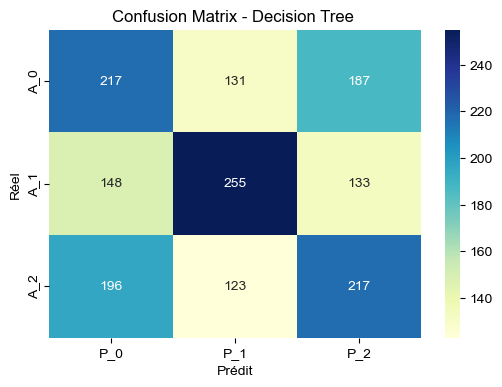


Classification Report – Decision Tree 

              precision    recall  f1-score   support

           0       0.39      0.41      0.40       535
           1       0.50      0.48      0.49       536
           2       0.40      0.40      0.40       536

    accuracy                           0.43      1607
   macro avg       0.43      0.43      0.43      1607
weighted avg       0.43      0.43      0.43      1607


Metrics – Decision Tree 
Model              Decision Tree 
AUC Score                 0.57156
MCC                      0.143195
Precision Score          0.430657
Recall Score             0.428749
f1-score                  0.42952
Accuracy Score           0.428749
Train Accuracy           0.993618
CV                       0.438126
dtype: object



In [175]:
# --- Decision Tree sur TF-IDF ---
dt_tfidf = DecisionTreeClassifier(random_state=200)
cv_scores = cross_val_score(dt_tfidf, X_train, y_train, cv=5, scoring='accuracy')
print(f"Decision Tree TF-IDF CV accuracy: {cv_scores}")
print(f"Moyenne: {np.mean(cv_scores):.4f}, Écart-type: {np.std(cv_scores):.4f}")
dt_tfidf.fit(X_train, y_train)
result_tabulation = Model_Evaluation1(dt_tfidf, "Decision Tree ", X_train , y_train, X_test, y_test, result_tabulation)


Decision Tree TF-IDF CV accuracy: [0.54396887 0.52062257 0.53229572 0.5229572  0.53504673]
Moyenne: 0.5310, Écart-type: 0.0085


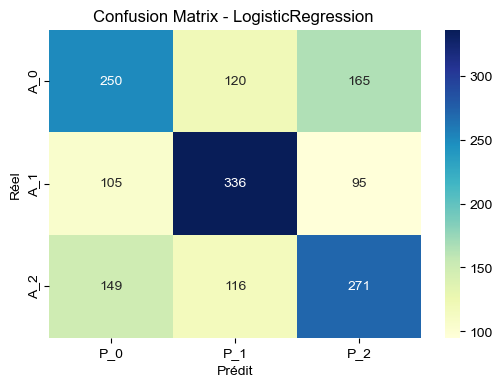


Classification Report – LogisticRegression 

              precision    recall  f1-score   support

           0       0.50      0.47      0.48       535
           1       0.59      0.63      0.61       536
           2       0.51      0.51      0.51       536

    accuracy                           0.53      1607
   macro avg       0.53      0.53      0.53      1607
weighted avg       0.53      0.53      0.53      1607


Metrics – LogisticRegression 
Model              LogisticRegression 
AUC Score                     0.649949
MCC                           0.300124
Precision Score               0.531289
Recall Score                  0.533292
f1-score                       0.53193
Accuracy Score                0.533292
Train Accuracy                0.558998
CV                            0.536425
dtype: object



In [176]:
# --- Decision Tree sur TF-IDF ---
lg_tfidf =LogisticRegression(random_state=200)
cv_scores = cross_val_score(lg_tfidf, X_train, y_train, cv=5, scoring='accuracy')
print(f"Decision Tree TF-IDF CV accuracy: {cv_scores}")
print(f"Moyenne: {np.mean(cv_scores):.4f}, Écart-type: {np.std(cv_scores):.4f}")
lg_tfidf.fit(X_train, y_train)
result_tabulation = Model_Evaluation1(lg_tfidf, "LogisticRegression ", X_train, y_train, X_test, y_test, result_tabulation)


Decision Tree TF-IDF CV accuracy: [0.53229572 0.5307393  0.52607004 0.53463035 0.56152648]
Moyenne: 0.5371, Écart-type: 0.0126


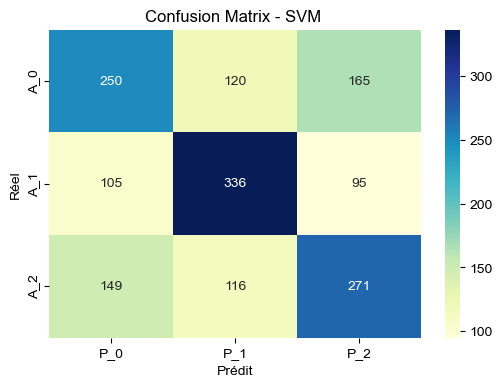


Classification Report – SVM 

              precision    recall  f1-score   support

           0       0.50      0.47      0.48       535
           1       0.59      0.63      0.61       536
           2       0.51      0.51      0.51       536

    accuracy                           0.53      1607
   macro avg       0.53      0.53      0.53      1607
weighted avg       0.53      0.53      0.53      1607


Metrics – SVM 
Model                  SVM 
AUC Score          0.649949
MCC                0.300124
Precision Score    0.531289
Recall Score       0.533292
f1-score            0.53193
Accuracy Score     0.533292
Train Accuracy     0.558998
CV                 0.536425
dtype: object



In [177]:
# --- Decision Tree sur TF-IDF ---
svm_tfidf =SVC()
cv_scores = cross_val_score(svm_tfidf, X_train, y_train, cv=5, scoring='accuracy')
print(f"Decision Tree TF-IDF CV accuracy: {cv_scores}")
print(f"Moyenne: {np.mean(cv_scores):.4f}, Écart-type: {np.std(cv_scores):.4f}")
svm_tfidf.fit(X_train, y_train)
result_tabulation = Model_Evaluation1(lg_tfidf, "SVM ", X_train, y_train, X_test, y_test, result_tabulation)


Decision Tree TF-IDF CV accuracy: [0.49338521 0.5463035  0.49805447 0.52373541 0.52803738]
Moyenne: 0.5179, Écart-type: 0.0197


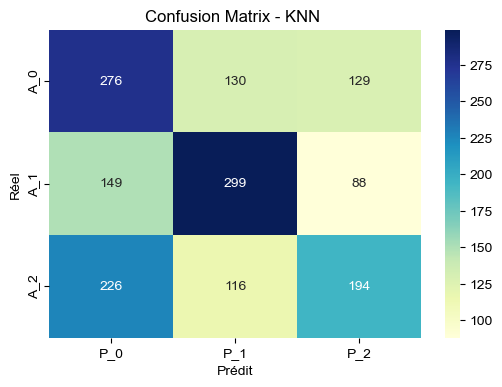


Classification Report – KNN 

              precision    recall  f1-score   support

           0       0.42      0.52      0.47       535
           1       0.55      0.56      0.55       536
           2       0.47      0.36      0.41       536

    accuracy                           0.48      1607
   macro avg       0.48      0.48      0.48      1607
weighted avg       0.48      0.48      0.48      1607


Metrics – KNN 
Model                  KNN 
AUC Score          0.608924
MCC                0.219718
Precision Score    0.481571
Recall Score       0.478531
f1-score           0.476119
Accuracy Score     0.478531
Train Accuracy     0.691625
CV                  0.51619
dtype: object



In [178]:
# --- Decision Tree sur TF-IDF ---
KNN =KNeighborsClassifier()
cv_scores = cross_val_score(KNN, X_train, y_train, cv=5, scoring='accuracy')
print(f"Decision Tree TF-IDF CV accuracy: {cv_scores}")
print(f"Moyenne: {np.mean(cv_scores):.4f}, Écart-type: {np.std(cv_scores):.4f}")
KNN.fit(X_train , y_train)
result_tabulation = Model_Evaluation1(KNN, "KNN ", X_train  , y_train, X_test , y_test, result_tabulation)


In [179]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Logistic Regression params: {'solver': 'saga', 'penalty': 'l2', 'max_iter': 1000, 'C': 0.004641588833612777}


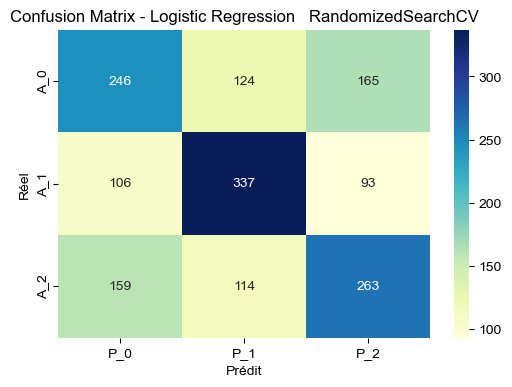


Classification Report – Logistic Regression   RandomizedSearchCV

              precision    recall  f1-score   support

           0       0.48      0.46      0.47       535
           1       0.59      0.63      0.61       536
           2       0.50      0.49      0.50       536

    accuracy                           0.53      1607
   macro avg       0.52      0.53      0.52      1607
weighted avg       0.52      0.53      0.52      1607


Metrics – Logistic Regression   RandomizedSearchCV
Model              Logistic Regression   RandomizedSearchCV
AUC Score                                          0.644816
MCC                                                0.289856
Precision Score                                    0.524125
Recall Score                                       0.526447
f1-score                                            0.52492
Accuracy Score                                     0.526447
Train Accuracy                                     0.554328
CV                  

In [180]:
param_dist_lr = {
    'C': np.logspace(-3, 3, 10),
    'solver': ['lbfgs', 'saga'],
    'penalty': ['l2'],
    'max_iter': [1000]
}

rs_lr = RandomizedSearchCV(
    LogisticRegression(),
    param_dist_lr,
    n_iter=20,
    scoring='accuracy',
    cv=5,
    n_jobs=4,
    verbose=1,
    random_state=42
)

rs_lr.fit(X_train , y_train)
print("Best Logistic Regression params:", rs_lr.best_params_)

best_lr = rs_lr.best_estimator_

result_tabulation_rse1 = Model_Evaluation1(
    best_lr,
    "Logistic Regression   RandomizedSearchCV",
    X_train , y_train,
    X_test , y_test,
    result_tabulation_rse1
)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best SVC params: {'kernel': 'rbf', 'gamma': 'auto', 'C': 7.742636826811277}


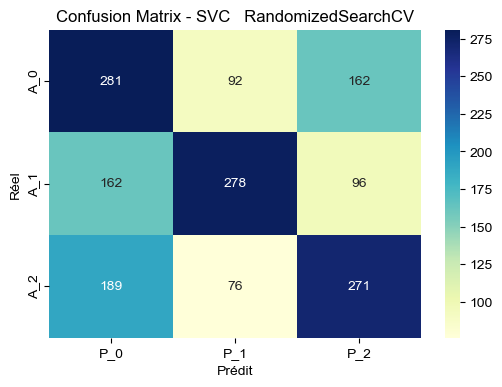


Classification Report – SVC   RandomizedSearchCV

              precision    recall  f1-score   support

           0       0.44      0.53      0.48       535
           1       0.62      0.52      0.57       536
           2       0.51      0.51      0.51       536

    accuracy                           0.52      1607
   macro avg       0.53      0.52      0.52      1607
weighted avg       0.53      0.52      0.52      1607


Metrics – SVC   RandomizedSearchCV
Model              SVC   RandomizedSearchCV
AUC Score                          0.637384
MCC                                0.276188
Precision Score                    0.526793
Recall Score                        0.51649
f1-score                           0.518919
Accuracy Score                      0.51649
Train Accuracy                     0.786426
CV                                 0.545686
dtype: object



In [181]:
param_dist_svc = {
    'C': np.logspace(-3, 2, 10),
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

rs_svc = RandomizedSearchCV(
    SVC(),
    param_dist_svc,
    n_iter=15,
    scoring='accuracy',
    cv=5,
    n_jobs=4,
    verbose=1,
    random_state=42
)

rs_svc.fit(X_train , y_train)
print("Best SVC params:", rs_svc.best_params_)

best_svc = rs_svc.best_estimator_

result_tabulation_rse1 = Model_Evaluation1(
    best_svc,
    "SVC   RandomizedSearchCV",
    X_train , y_train,
    X_test, y_test,
    result_tabulation_rse1
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best KNN params: {'weights': 'distance', 'n_neighbors': 9, 'metric': 'manhattan'}


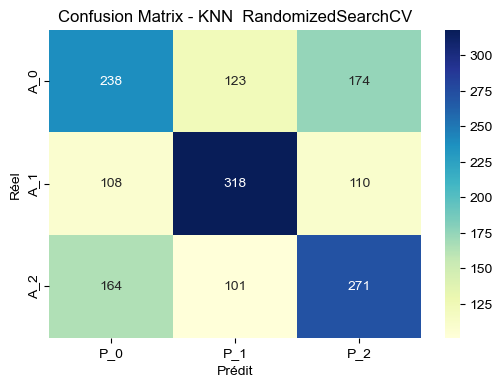


Classification Report – KNN  RandomizedSearchCV

              precision    recall  f1-score   support

           0       0.47      0.44      0.46       535
           1       0.59      0.59      0.59       536
           2       0.49      0.51      0.50       536

    accuracy                           0.51      1607
   macro avg       0.51      0.51      0.51      1607
weighted avg       0.51      0.51      0.51      1607


Metrics – KNN  RandomizedSearchCV
Model              KNN  RandomizedSearchCV
AUC Score                         0.635948
MCC                               0.272005
Precision Score                    0.51392
Recall Score                      0.514624
f1-score                          0.514128
Accuracy Score                    0.514624
Train Accuracy                    0.993462
CV                                0.536816
dtype: object



In [182]:
param_dist_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

rs_knn = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_dist_knn,
    n_iter=10,
    scoring='accuracy',
    cv=5,
    n_jobs=6,
    verbose=1,
    random_state=42
)

rs_knn.fit(X_train , y_train)
print("Best KNN params:", rs_knn.best_params_)

best_knn = rs_knn.best_estimator_

result_tabulation_rse1 = Model_Evaluation1(
    best_knn,
    "KNN  RandomizedSearchCV",
    X_train , y_train,
    X_test , y_test,
    result_tabulation_rse1
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Random Forest params: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 50, 'bootstrap': False}


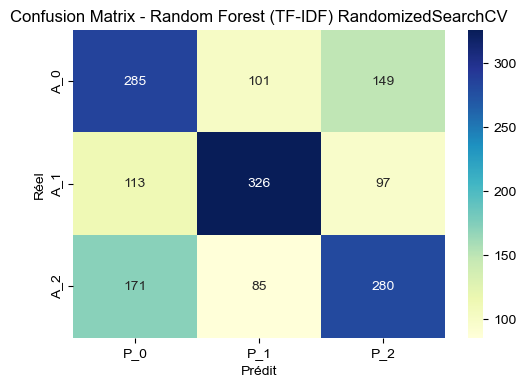


Classification Report – Random Forest (TF-IDF) RandomizedSearchCV

              precision    recall  f1-score   support

           0       0.50      0.53      0.52       535
           1       0.64      0.61      0.62       536
           2       0.53      0.52      0.53       536

    accuracy                           0.55      1607
   macro avg       0.56      0.55      0.56      1607
weighted avg       0.56      0.55      0.56      1607


Metrics – Random Forest (TF-IDF) RandomizedSearchCV
Model              Random Forest (TF-IDF) RandomizedSearchCV
AUC Score                                           0.665837
MCC                                                 0.331863
Precision Score                                     0.556674
Recall Score                                        0.554449
f1-score                                            0.555274
Accuracy Score                                      0.554449
Train Accuracy                                      0.993462
CV        

In [183]:
param_dist_rf = {
    'n_estimators': [100, 500, 300],
    'max_depth': [None, 10, 20, 50],
    'min_samples_split': [2, 1, 10],
    'min_samples_leaf': [6, 2, 4],
    'bootstrap': [True, False]
}

rs_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist_rf,
    n_iter=10,
    scoring='accuracy',
    cv=5,
    n_jobs=6,
    verbose=1,
    random_state=42
)

rs_rf.fit(X_train, y_train)
print("Best Random Forest params:", rs_rf.best_params_)

best_rf = rs_rf.best_estimator_

result_tabulation_rse1 = Model_Evaluation1(
    best_rf,
    "Random Forest (TF-IDF) RandomizedSearchCV",
    X_train, y_train,
    X_test, y_test,
    result_tabulation_rse1
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best AdaBoost params: {'n_estimators': 200, 'learning_rate': 1.0}


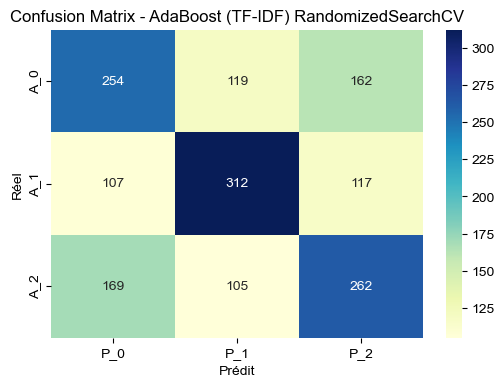


Classification Report – AdaBoost (TF-IDF) RandomizedSearchCV

              precision    recall  f1-score   support

           0       0.48      0.47      0.48       535
           1       0.58      0.58      0.58       536
           2       0.48      0.49      0.49       536

    accuracy                           0.52      1607
   macro avg       0.52      0.52      0.52      1607
weighted avg       0.52      0.52      0.52      1607


Metrics – AdaBoost (TF-IDF) RandomizedSearchCV
Model              AdaBoost (TF-IDF) RandomizedSearchCV
AUC Score                                      0.636424
MCC                                             0.27287
Precision Score                                 0.51523
Recall Score                                   0.515246
f1-score                                       0.515231
Accuracy Score                                 0.515246
Train Accuracy                                 0.604452
CV                                             0.503189
dtyp

In [184]:
param_dist_ab = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0, 2.0]
}

rs_ab = RandomizedSearchCV(
    AdaBoostClassifier(random_state=42),
    param_dist_ab,
    n_iter=10,
    scoring='accuracy',
    cv=5,
    n_jobs=6,
    verbose=1,
    random_state=42
)

rs_ab.fit(X_train , y_train)
print("Best AdaBoost params:", rs_ab.best_params_)

best_ab = rs_ab.best_estimator_

result_tabulation_rse1 = Model_Evaluation1(
    best_ab,
    "AdaBoost (TF-IDF) RandomizedSearchCV",
    X_train , y_train,
    X_test , y_test,
    result_tabulation_rse1
)

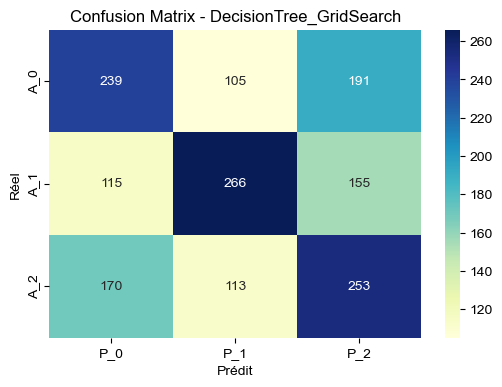


Classification Report – DecisionTree_GridSearch

              precision    recall  f1-score   support

           0       0.46      0.45      0.45       535
           1       0.55      0.50      0.52       536
           2       0.42      0.47      0.45       536

    accuracy                           0.47      1607
   macro avg       0.48      0.47      0.47      1607
weighted avg       0.48      0.47      0.47      1607


Metrics – DecisionTree_GridSearch
Model              DecisionTree_GridSearch
AUC Score                         0.603757
MCC                               0.207935
Precision Score                   0.476034
Recall Score                      0.471686
f1-score                          0.472931
Accuracy Score                    0.471686
Train Accuracy                    0.558998
CV                                0.458515
dtype: object



In [185]:
DecisionTree_GridSearch = DecisionTreeClassifier( criterion = 'gini', max_leaf_nodes  = 54,  min_samples_split = 2, random_state  = 0 )
DecisionTree_GridSearch.fit(X_train,y_train)
result_tabulation_rse1 = Model_Evaluation1(
    DecisionTree_GridSearch,
    "DecisionTree_GridSearch",
    X_train , y_train,
    X_test , y_test,
    result_tabulation_rse1
)

In [186]:
param_grid = {'max_leaf_nodes'           :   list(range(50, 55)), 
              'min_samples_split'        :   list(range(2, 6)),
              'criterion'                :   ["gini", "entropy"],
              'random_state'             :    np.arange(0,300,50)
              }
DecisionTree_GridSearch = GridSearchCV(DecisionTreeClassifier(),param_grid, cv=5)
DecisionTree_GridSearch.fit(X_train,y_train)
print("best score: ", DecisionTree_GridSearch.best_score_) 
print("best param: ", DecisionTree_GridSearch.best_params_)

best score:  0.4589065056911161
best param:  {'criterion': 'gini', 'max_leaf_nodes': 54, 'min_samples_split': 2, 'random_state': 0}


In [187]:
result_tabulation_rse1

,Model,AUC Score,MCC,Precision Score,Recall Score,f1-score,Accuracy Score,Train Accuracy,CV
0,Logistic Regression RandomizedSearchCV,0.644816,0.289856,0.524125,0.526447,0.52492,0.526447,0.554328,0.534634
1,SVC RandomizedSearchCV,0.637384,0.276188,0.526793,0.51649,0.518919,0.51649,0.786426,0.545686
2,KNN RandomizedSearchCV,0.635948,0.272005,0.51392,0.514624,0.514128,0.514624,0.993462,0.536816
3,Random Forest (TF-IDF) RandomizedSearchCV,0.665837,0.331863,0.556674,0.554449,0.555274,0.554449,0.993462,0.568181
4,AdaBoost (TF-IDF) RandomizedSearchCV,0.636424,0.27287,0.51523,0.515246,0.515231,0.515246,0.604452,0.503189
5,DecisionTree_GridSearch,0.603757,0.207935,0.476034,0.471686,0.472931,0.471686,0.558998,0.458515
